<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Spoofed_Traffic_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 131.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/

In [1]:
pip show sionna


Name: sionna
Version: 2.0.1
Summary: Sionna - A hardware-accelerated differentiable open-source library for research on communication systems
Home-page: 
Author: 
Author-email: The Sionna contributors <sionna@nvidia.com>
License: Apache-2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: h5py, importlib-resources, matplotlib, numpy, scipy, sionna-rt, torch
Required-by: 


In [2]:
import tensorflow as tf
import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation area (meters)
AREA_X = 1000
AREA_Y = 1000

print("Simulation Area:", AREA_X, "x", AREA_Y, "meters")

Simulation Area: 1000 x 1000 meters


In [4]:
bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

print(bs_positions)

[[250 250]
 [750 250]
 [500 750]]


In [5]:
num_users = 30

user_positions = np.random.rand(num_users,2)

user_positions[:,0] *= AREA_X
user_positions[:,1] *= AREA_Y

print(user_positions)

[[4.17035781e+02 6.65623576e+02]
 [7.67320057e+01 1.25915987e+02]
 [7.68459020e-02 3.85439714e+02]
 [7.77917172e+02 2.11320986e+02]
 [6.90060373e+02 3.81551874e+02]
 [9.05138219e+01 1.10514682e+02]
 [9.09771551e+02 4.93129316e+02]
 [8.82015904e+02 5.74502383e+02]
 [5.27154710e+02 4.27476700e+02]
 [2.68715135e+02 3.71228074e+02]
 [3.77188365e+02 8.67973476e+02]
 [6.76767963e+02 3.52528784e+02]
 [8.86779751e+02 1.31186944e+02]
 [7.29681236e+02 3.43115945e+02]
 [1.67902845e+01 8.62944553e+02]
 [6.35121651e+02 3.98125551e+02]
 [5.43261942e+02 9.63781076e+02]
 [2.75450141e+02 4.47008818e+01]
 [3.08473323e+01 3.73971472e+02]
 [9.85912175e+02 2.93481412e+02]
 [8.53533273e+01 3.27871552e+02]
 [7.14742008e+01 6.13707102e+02]
 [4.14998113e+02 9.21402766e+02]
 [6.30177256e+02 1.28335003e+02]
 [7.73080903e+02 7.15236365e+02]
 [7.90571818e+02 9.91717471e+02]
 [7.05368834e+02 7.85039505e+01]
 [7.50355885e+02 2.92128191e+02]
 [3.81261968e+02 2.65992837e+02]
 [2.56722011e+02 4.15493622e+02]]


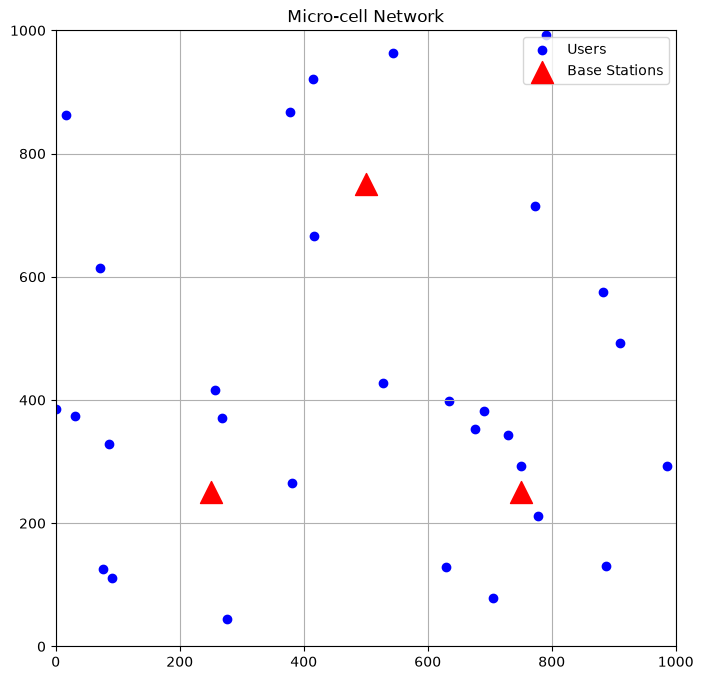

In [6]:
plt.figure(figsize=(8,8))

# Users
plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c='blue',
    label='Users'
)

# Base Stations
plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    c='red',
    s=250,
    marker='^',
    label='Base Stations'
)

plt.xlim(0,AREA_X)
plt.ylim(0,AREA_Y)

plt.grid(True)
plt.legend()

plt.title("Micro-cell Network")

plt.savefig("figures_network_layout_1.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
import tensorflow as tf
import sionna
import numpy as np
import matplotlib.pyplot as plt


# Distance matrix
distance_matrix = np.zeros((len(user_positions), len(bs_positions)))

for i, user in enumerate(user_positions):

    for j, bs in enumerate(bs_positions):

        distance = np.linalg.norm(user-bs)

        distance_matrix[i,j] = distance

print(distance_matrix)

[[447.93292869 532.54870956 118.3319175 ]
 [213.11649451 684.6069197  754.08000293]
 [284.26308068 762.05554465 618.73044393]
 [529.33222683  47.70151582 606.14605055]
 [459.30276269 144.56366925 414.58047092]
 [211.87731113 674.07579175 759.35525424]
 [703.14320263 290.92750437 483.62720339]
 [710.45471352 350.32841133 420.39929172]
 [329.10896685 284.882436   323.6644211 ]
 [122.66418476 496.31780889 443.80272725]
 [630.92638062 721.71998213 170.29515197]
 [438.91120455 125.9963603  435.00606927]
 [647.76924397 181.17737854 729.74528005]
 [488.63551598  95.30703751 467.23452819]
 [655.81079338 955.66600453 496.23391788]
 [412.62557454 187.45189769 376.92637004]
 [771.67738781 743.11778911 218.11452033]
 [206.87058189 517.05444224 740.1820622 ]
 [251.78724679 729.759882   601.25009731]
 [737.19560673 239.88578015 666.72322833]
 [182.1332079  669.1929304  591.71301309]
 [405.15961901 769.85720501 449.67778989]
 [691.37981733 750.33854944 191.3223172 ]
 [399.17053716 170.76258741 635.14

In [8]:
assignments = np.argmin(distance_matrix, axis=1)

print(assignments)

[2 0 0 1 1 0 1 1 1 0 2 1 1 1 2 1 2 0 0 1 0 0 2 1 2 2 1 1 0 0]


In [9]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments==bs)

    print(f"BS {bs+1} has {count} users")

BS 1 has 10 users
BS 2 has 13 users
BS 3 has 7 users


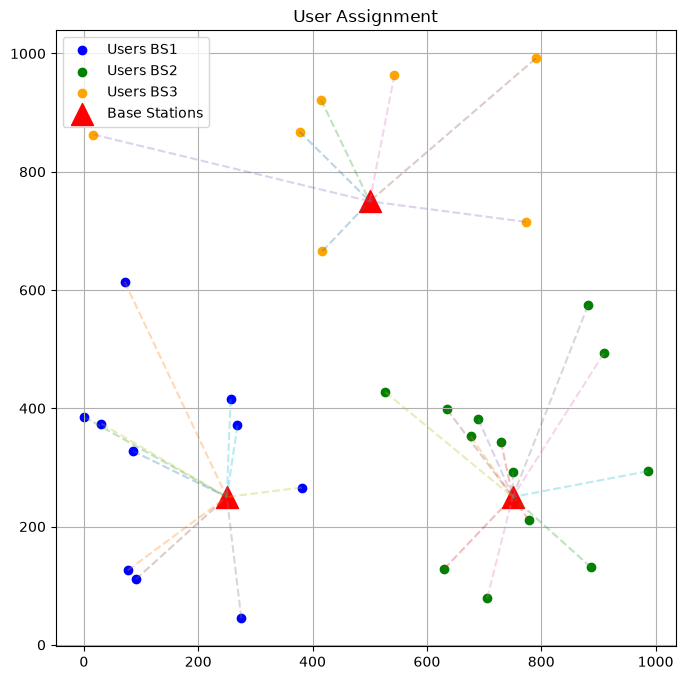

In [10]:
plt.figure(figsize=(8,8))

colors=['blue','green','orange']

# Draw users

for bs in range(3):

    idx = assignments==bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users BS{bs+1}'
    )

# Draw Base Stations

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=250,
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs=assignments[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3
    )

plt.grid()

plt.legend()

plt.title("User Assignment")

plt.savefig("figures_network_layout_2.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
import pandas as pd

results = pd.DataFrame({
    "User": range(1, len(assignments)+1),
    "Assigned_BS": assignments
})

results.to_csv("user_assignment.csv", index=False)

In [12]:
# -------------------------------
# Network Parameters
# -------------------------------

frequency = 3500      # MHz (5G frequency)
tx_power = 30         # dBm (micro-cell transmit power)

print("Frequency:", frequency, "MHz")
print("Transmit Power:", tx_power, "dBm")

Frequency: 3500 MHz
Transmit Power: 30 dBm


In [13]:
distance_matrix
print(distance_matrix)

[[447.93292869 532.54870956 118.3319175 ]
 [213.11649451 684.6069197  754.08000293]
 [284.26308068 762.05554465 618.73044393]
 [529.33222683  47.70151582 606.14605055]
 [459.30276269 144.56366925 414.58047092]
 [211.87731113 674.07579175 759.35525424]
 [703.14320263 290.92750437 483.62720339]
 [710.45471352 350.32841133 420.39929172]
 [329.10896685 284.882436   323.6644211 ]
 [122.66418476 496.31780889 443.80272725]
 [630.92638062 721.71998213 170.29515197]
 [438.91120455 125.9963603  435.00606927]
 [647.76924397 181.17737854 729.74528005]
 [488.63551598  95.30703751 467.23452819]
 [655.81079338 955.66600453 496.23391788]
 [412.62557454 187.45189769 376.92637004]
 [771.67738781 743.11778911 218.11452033]
 [206.87058189 517.05444224 740.1820622 ]
 [251.78724679 729.759882   601.25009731]
 [737.19560673 239.88578015 666.72322833]
 [182.1332079  669.1929304  591.71301309]
 [405.15961901 769.85720501 449.67778989]
 [691.37981733 750.33854944 191.3223172 ]
 [399.17053716 170.76258741 635.14

In [14]:
distance_km = distance_matrix / 1000

# Avoid log10(0)
distance_km[distance_km < 0.001] = 0.001

import numpy as np

path_loss = 32.44 \
            + 20*np.log10(frequency) \
            + 20*np.log10(distance_km)

print(path_loss)

[[ 96.34562068  97.84854762  84.78339893]
 [ 89.89370217 100.03018658 100.86970937]
 [ 92.39577005 100.96109343  99.1513906 ]
 [ 97.7959276   76.89200448  98.97290648]
 [ 96.56334204  86.52254414  95.6735377 ]
 [ 89.84304994  99.8955355  100.93026093]
 [100.26223654  92.59705652  97.01157531]
 [100.35208889  94.21086808  95.7946004 ]
 [ 93.66815519  92.41467437  93.52326013]
 [ 85.09571642  97.23655806  96.26516022]
 [ 99.32093462 100.48873548  87.94540658]
 [ 96.16889424  85.32852088  96.09126721]
 [ 99.54976736  88.48344032 100.58478678]
 [ 97.10106149  82.90386029  96.71205947]
 [ 99.65693209 102.92748363  97.23508979]
 [ 95.63248373  88.77915772  94.84649133]
 [101.07007638 100.74251404  90.09505246]
 [ 89.63533561  97.59208636 100.70813201]
 [ 91.34203547 100.58496058  98.90246408]
 [100.67301566  90.92145098  99.80027261]
 [ 88.52914362  99.83238777  98.7635833 ]
 [ 95.47388397 101.04956446  96.37938964]
 [100.11569484 100.82650607  88.95667353]
 [ 95.34453046  87.96921542  99.37

In [15]:
received_power = tx_power - path_loss

print(received_power)

[[-66.34562068 -67.84854762 -54.78339893]
 [-59.89370217 -70.03018658 -70.86970937]
 [-62.39577005 -70.96109343 -69.1513906 ]
 [-67.7959276  -46.89200448 -68.97290648]
 [-66.56334204 -56.52254414 -65.6735377 ]
 [-59.84304994 -69.8955355  -70.93026093]
 [-70.26223654 -62.59705652 -67.01157531]
 [-70.35208889 -64.21086808 -65.7946004 ]
 [-63.66815519 -62.41467437 -63.52326013]
 [-55.09571642 -67.23655806 -66.26516022]
 [-69.32093462 -70.48873548 -57.94540658]
 [-66.16889424 -55.32852088 -66.09126721]
 [-69.54976736 -58.48344032 -70.58478678]
 [-67.10106149 -52.90386029 -66.71205947]
 [-69.65693209 -72.92748363 -67.23508979]
 [-65.63248373 -58.77915772 -64.84649133]
 [-71.07007638 -70.74251404 -60.09505246]
 [-59.63533561 -67.59208636 -70.70813201]
 [-61.34203547 -70.58496058 -68.90246408]
 [-70.67301566 -60.92145098 -69.80027261]
 [-58.52914362 -69.83238777 -68.7635833 ]
 [-65.47388397 -71.04956446 -66.37938964]
 [-70.11569484 -70.82650607 -58.95667353]
 [-65.34453046 -57.96921542 -69.37

In [16]:
assignments_signal = np.argmax(received_power, axis=1)

print(assignments_signal)


[2 0 0 1 1 0 1 1 1 0 2 1 1 1 2 1 2 0 0 1 0 0 2 1 2 2 1 1 0 0]


In [17]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments_signal == bs)

    print(f"BS {bs+1}: {count} users")

BS 1: 10 users
BS 2: 13 users
BS 3: 7 users


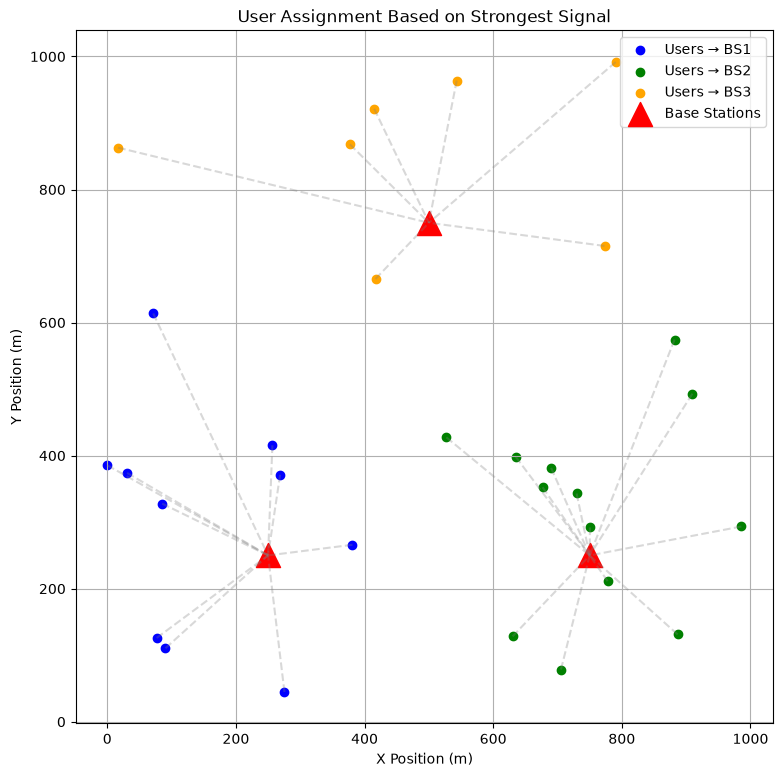

In [18]:
plt.figure(figsize=(9,9))

colors = ['blue','green','orange']

for bs in range(3):

    idx = assignments_signal == bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users → BS{bs+1}'
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    s=300,
    color='red',
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs = assignments_signal[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3,
        color='gray'
    )

plt.title("User Assignment Based on Strongest Signal")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step4_user_assignment_signal.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [19]:
import pandas as pd

results = pd.DataFrame({
    "User": np.arange(1, len(user_positions)+1),
    "Assigned_BS": assignments_signal + 1,
    "Best_RSRP_dBm": np.max(received_power, axis=1)
})

print(results.head())

results.to_csv("step4_user_assignment.csv", index=False)

   User  Assigned_BS  Best_RSRP_dBm
0     1            3     -54.783399
1     2            1     -59.893702
2     3            1     -62.395770
3     4            2     -46.892004
4     5            2     -56.522544


In [20]:
#STEP 5 - SINR Calculation
# Convert dBm to mW

received_power_mW = 10 ** (received_power / 10)

print(received_power_mW)

[[2.31973263e-07 1.64113852e-07 3.32399305e-06]
 [1.02477798e-06 9.93073384e-08 8.18519562e-08]
 [5.76000678e-07 8.01476248e-08 1.21579664e-07]
 [1.66114384e-07 2.04550032e-05 1.26680378e-07]
 [2.20630625e-07 2.22713009e-06 2.70798485e-07]
 [1.03680004e-06 1.02434547e-07 8.07186531e-08]
 [9.41404664e-08 5.49913458e-07 1.98995139e-07]
 [9.22127792e-08 3.79239174e-07 2.63354025e-07]
 [4.29718925e-07 5.73498865e-07 4.44297620e-07]
 [3.09334499e-06 1.88948824e-07 2.36311022e-07]
 [1.16924774e-07 8.93565622e-08 1.60494200e-06]
 [2.41607591e-07 2.93189162e-06 2.45964981e-07]
 [1.10923423e-07 1.41793384e-06 8.74019902e-08]
 [1.94936808e-07 5.12405722e-06 2.13203364e-07]
 [1.08219816e-07 5.09626070e-08 1.89012715e-07]
 [2.73370487e-07 1.32459841e-06 3.27605261e-07]
 [7.81614059e-08 8.42846710e-08 9.78351138e-07]
 [1.08759309e-06 1.74097031e-07 8.49545804e-08]
 [7.34169694e-07 8.73984925e-08 1.28751884e-07]
 [8.56442942e-08 8.08825624e-07 1.04706282e-07]
 [1.40309035e-06 1.03934857e-07 1.329357

In [21]:
# Thermal Noise (Assume a simple fixed thermal noise power)
noise_dBm = -100

noise_mW = 10 ** (noise_dBm / 10)

print("Noise Power (mW):", noise_mW)

Noise Power (mW): 1e-10


In [22]:
# Calculate SINR
sinr = []

for i in range(len(user_positions)):

    serving_bs = assignments_signal[i]

    signal = received_power_mW[i, serving_bs]

    interference = np.sum(received_power_mW[i]) - signal

    sinr_linear = signal / (interference + noise_mW)

    sinr.append(sinr_linear)

sinr = np.array(sinr)

# Convert SINR to dB
sinr_dB = 10 * np.log10(sinr)

print(sinr_dB)

[ 9.2375976   7.52329498  4.55443107 18.44087946  6.56196342  7.52643439
  2.73077645  0.2786986  -1.83036778  8.61671868  8.90788923  7.79019581
  8.54058675 10.98698232  0.74323167  3.43155023  7.79518262  6.22912526
  5.30839581  6.2807261   7.72391224 -0.37076893  8.48718931  5.92859381
  2.97516655  3.6774348   7.0689536  18.67705515  7.0158456   5.82110206]


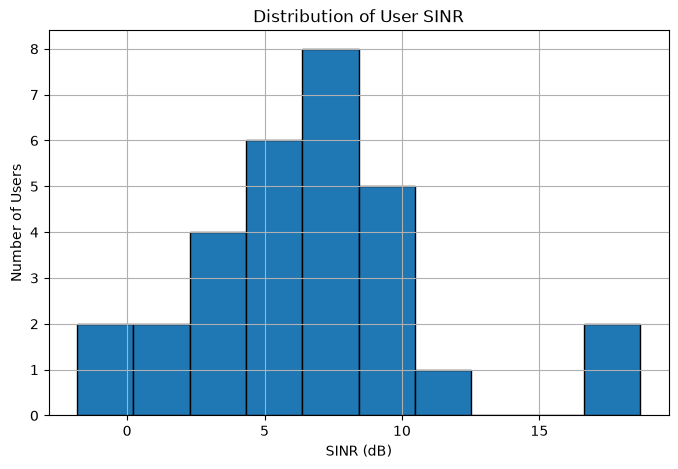

In [23]:
# Plot SINR Distribution
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=10,
         edgecolor='black')

plt.xlabel("SINR (dB)")
plt.ylabel("Number of Users")
plt.title("Distribution of User SINR")

plt.grid(True)

plt.savefig("figures_step5_sinr_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

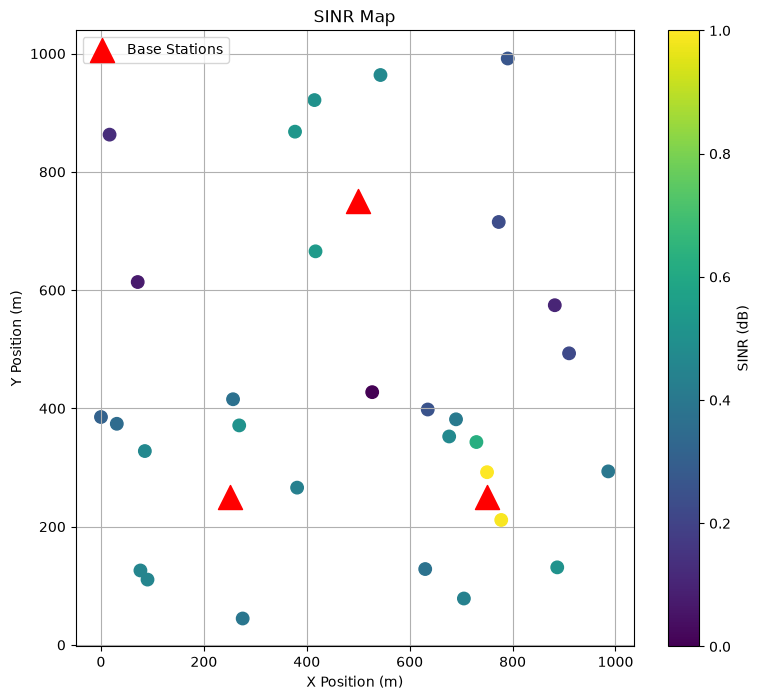

In [24]:
# Network Visualization
plt.figure(figsize=(9,8))

plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c=sinr_dB,
    cmap='viridis',
    s=80
)

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=300,
    label='Base Stations'
)

plt.colorbar(label="SINR (dB)")

plt.title("SINR Map")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step5_sinr_map.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [25]:
# Statistics
print("Average SINR :", np.mean(sinr_dB))

print("Maximum SINR :", np.max(sinr_dB))

print("Minimum SINR :", np.min(sinr_dB))

Average SINR : 6.555292561931989
Maximum SINR : 18.677055147019146
Minimum SINR : -1.8303677810838883


In [26]:
# Save Results
results["SINR_dB"] = sinr_dB

results.to_csv(
    "results_step5_sinr_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB
0     1            3     -54.783399   9.237598
1     2            1     -59.893702   7.523295
2     3            1     -62.395770   4.554431
3     4            2     -46.892004  18.440879
4     5            2     -56.522544   6.561963


In [27]:
#====================================================
# STEP 6 - QoS Analysis
#====================================================

# Spectral Efficiency (bits/s/Hz)

spectral_efficiency = np.log2(1 + sinr)

print(spectral_efficiency)


[3.23111863 2.73414761 1.94632985 6.14643897 2.46754655 2.73503381
 1.52372742 1.04703336 0.72778082 3.04828874 3.13365969 2.80982773
 3.02607917 3.76038865 1.12872326 1.67974489 2.81124818 2.37760812
 2.13586266 2.39146684 2.7909696  0.9397306  3.01053027 2.2975291
 1.57719229 1.73642312 2.60693528 6.22381646 2.59220393 2.26915647]


In [28]:
# Bandwidth per user

bandwidth = 20e6      # 20 MHz

throughput = bandwidth * spectral_efficiency

throughput_Mbps = throughput / 1e6

print(throughput_Mbps)

[ 64.62237253  54.68295224  38.92659706 122.92877948  49.35093094
  54.7006762   30.47454844  20.94066719  14.55561639  60.9657749
  62.67319382  56.19655465  60.5215835   75.207773    22.57446524
  33.59489774  56.22496363  47.5521624   42.71725319  47.82933683
  55.81939199  18.79461198  60.2106054   45.95058201  31.5438458
  34.72846243  52.1387056  124.47632927  51.84407865  45.38312946]


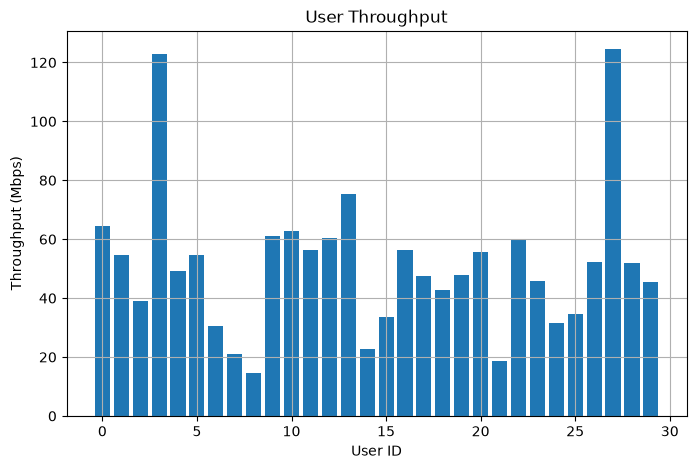

In [29]:
# Plot Throughput

plt.figure(figsize=(8,5))

plt.bar(range(len(throughput_Mbps)),
        throughput_Mbps)

plt.xlabel("User ID")
plt.ylabel("Throughput (Mbps)")
plt.title("User Throughput")

plt.grid(True)

plt.savefig(
    "figures_step6_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Average Throughput
print("Average Throughput:")

print(np.mean(throughput_Mbps),"Mbps")

Average Throughput:
51.27102806445908 Mbps


In [31]:
# Packet Error Rate (PER)
packet_error_rate = np.exp(-sinr)

print(packet_error_rate)

[2.27136934e-04 3.50467484e-03 5.76175181e-02 4.67746655e-31
 1.07696446e-02 3.49037568e-03 1.53304405e-01 3.44288072e-01
 5.18876333e-01 6.94511828e-04 4.19442128e-04 2.44916424e-03
 7.88066064e-04 3.53932266e-06 3.05241678e-01 1.10392515e-01
 2.43230546e-03 1.50444750e-02 3.35406059e-02 1.43084411e-02
 2.68265666e-03 3.99248992e-01 8.59976204e-04 1.99176190e-02
 1.37533778e-01 9.70935637e-02 6.14521432e-03 9.43950666e-33
 6.53755539e-03 2.19187674e-02]


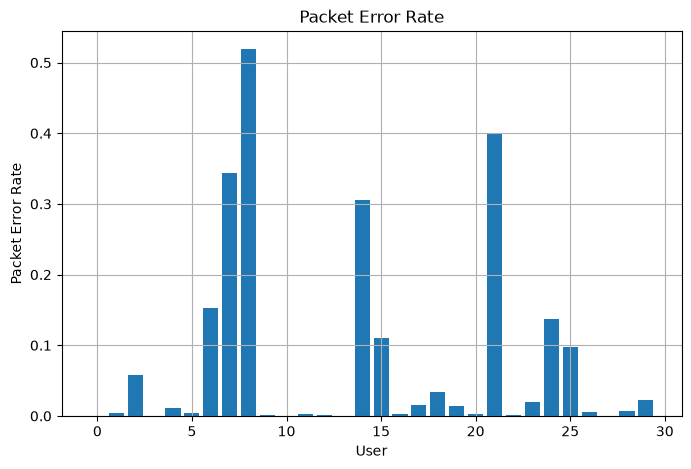

In [32]:
# Plot PER
plt.figure(figsize=(8,5))

plt.bar(range(len(packet_error_rate)),
        packet_error_rate)

plt.xlabel("User")

plt.ylabel("Packet Error Rate")

plt.title("Packet Error Rate")

plt.grid(True)

plt.savefig(
    "figures_step6_packet_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Latency Model
latency = 100/(sinr+1)

print(latency)

[10.64967548 15.02932778 25.94754853  1.41168403 18.07983546 15.02009861
 34.77861963 48.39623226 60.38320256 12.08853445 11.39395335 14.26124924
 12.27607121  7.37921597 45.73202596 31.2137828  14.2472148  19.24281648
 22.75313654 19.05885242 14.4488883  52.13302216 12.40909433 20.34111827
 33.51334766 30.01128252 16.41475043  1.3379644  16.58321997 20.74511453]


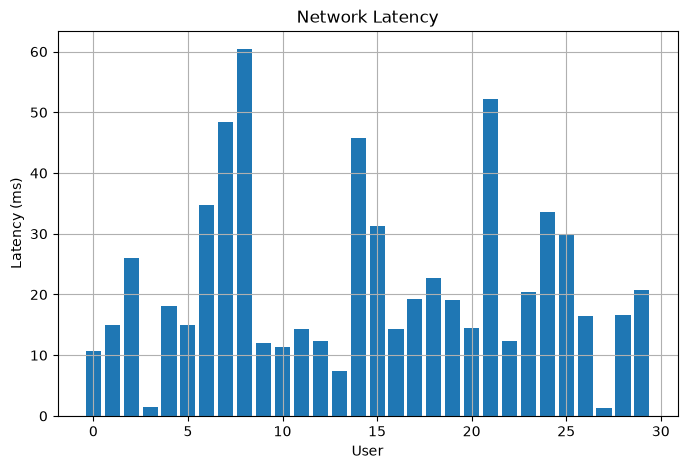

In [34]:
# Plot Latency
plt.figure(figsize=(8,5))

plt.bar(range(len(latency)),
        latency)

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Network Latency")

plt.grid(True)

plt.savefig(
    "figures_step6_latency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# QoS Summary
print("========== QoS SUMMARY ==========")

print("Average SINR:",
      np.mean(sinr_dB),
      "dB")

print("Average Throughput:",
      np.mean(throughput_Mbps),
      "Mbps")

print("Average Latency:",
      np.mean(latency),
      "ms")

print("Average PER:",
      np.mean(packet_error_rate))

========== QoS SUMMARY ==========
Average SINR: 6.555292561931989 dB
Average Throughput: 51.27102806445908 Mbps
Average Latency: 21.909362669654517 ms
Average PER: 0.07564436755595018


In [36]:
# Save Results
results["SINR_dB"] = sinr_dB
results["Spectral_Efficiency"] = spectral_efficiency
results["Throughput_Mbps"] = throughput_Mbps
results["Latency_ms"] = latency
results["PER"] = packet_error_rate

results.to_csv(
    "results_step6_qos_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm    SINR_dB  Spectral_Efficiency  \
0     1            3     -54.783399   9.237598             3.231119   
1     2            1     -59.893702   7.523295             2.734148   
2     3            1     -62.395770   4.554431             1.946330   
3     4            2     -46.892004  18.440879             6.146439   
4     5            2     -56.522544   6.561963             2.467547   

   Throughput_Mbps  Latency_ms           PER  
0        64.622373   10.649675  2.271369e-04  
1        54.682952   15.029328  3.504675e-03  
2        38.926597   25.947549  5.761752e-02  
3       122.928779    1.411684  4.677467e-31  
4        49.350931   18.079835  1.076964e-02  


In [37]:
# Step 7
# Save normal network results

normal_throughput = throughput_Mbps.copy()
normal_latency = latency.copy()
normal_per = packet_error_rate.copy()
normal_assignments = assignments_signal.copy()

In [38]:
# Number of users connected to each BS

cell_load = np.zeros(len(bs_positions), dtype=int)

for bs in assignments_signal:
    cell_load[bs] += 1

print("Current Cell Load")

for i, load in enumerate(cell_load):
    print(f"BS{i+1}: {load} users")

Current Cell Load
BS1: 10 users
BS2: 13 users
BS3: 7 users


In [39]:
#----------------------------------------
# Spoofed Traffic Attack
#----------------------------------------

target_bs = 1      # BS2 (index starts from 0)

spoofed_users = 20

print("Attack Target : BS", target_bs+1)
print("Fake Users :", spoofed_users)

Attack Target : BS 2
Fake Users : 20


In [40]:
# Increase Cell Load
attack_cell_load = cell_load.copy()

attack_cell_load[target_bs] += spoofed_users

print("Cell Load After Attack")

for i, load in enumerate(attack_cell_load):
    print(f"BS{i+1}: {load} users")

Cell Load After Attack
BS1: 10 users
BS2: 33 users
BS3: 7 users


In [41]:
# Available Bandwidth Per Cell
total_bandwidth = 20e6      #20 MHz

bandwidth_per_bs = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):
    bandwidth_per_bs[i] = total_bandwidth / attack_cell_load[i]

print(bandwidth_per_bs)

[2000000.          606060.60606061 2857142.85714286]


In [42]:
# Calculate New Throughput
attack_throughput = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    attack_bandwidth = bandwidth_per_bs[bs]

    attack_throughput[i] = (
        attack_bandwidth
        * spectral_efficiency[i]
        / 1e6
    )

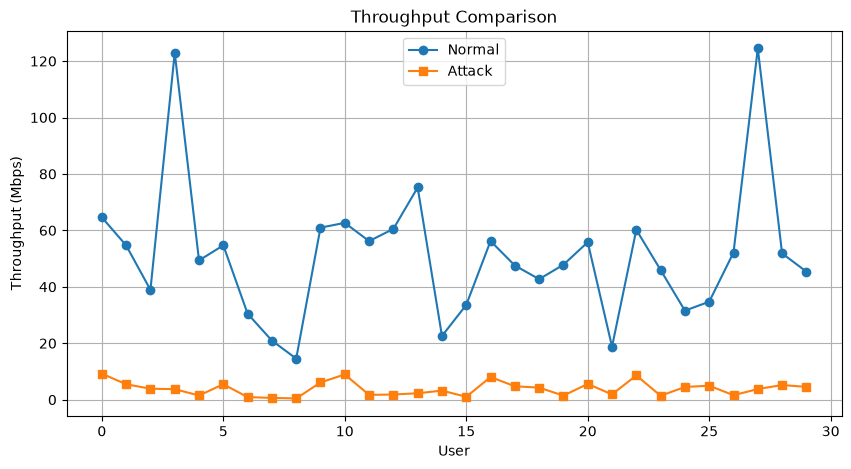

In [43]:
# Plot Throughput Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_throughput,
         marker='o',
         label="Normal")

plt.plot(attack_throughput,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Throughput (Mbps)")

plt.title("Throughput Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_throughput_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# New Latency
attack_latency = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    load_factor = attack_cell_load[bs] / cell_load[bs]

    attack_latency[i] = latency[i] * load_factor

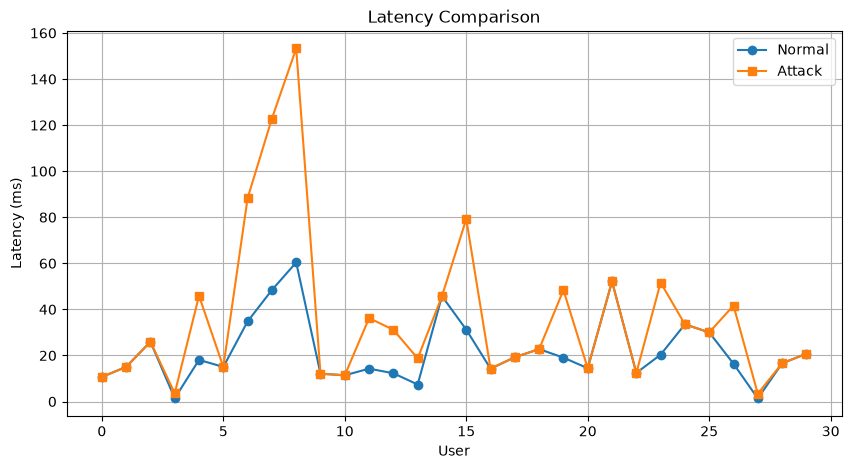

In [45]:
# Plot Latency Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_latency,
         marker='o',
         label="Normal")

plt.plot(attack_latency,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Latency Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# QoS Comparison
print("========== NORMAL ==========")

print("Average Throughput:",
      np.mean(normal_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(normal_latency),
      "ms")

print("\n========== ATTACK ==========")

print("Average Throughput:",
      np.mean(attack_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(attack_latency),
      "ms")

========== NORMAL ==========
Average Throughput: 51.27102806445908 Mbps
Average Latency: 21.909362669654517 ms

========== ATTACK ==========
Average Throughput: 3.8965752143240993 Mbps
Average Latency: 36.541802600799784 ms


In [47]:
# Save Results
attack_results = results.copy()

attack_results["Attack_Throughput_Mbps"] = attack_throughput
attack_results["Attack_Latency_ms"] = attack_latency

attack_results.to_csv(
    "results_step7_attack_results.csv",
    index=False
)

In [48]:
# ====================================================
# STEP 7A - Legitimate Traffic Generation
# ====================================================

# Simulation Parameters
import numpy as np

simulation_time = 10          # seconds

packet_size = 1500            # Bytes

time_step = 1                 # second

# Legitimate Traffic
np.random.seed(42)

traffic_rate = np.random.randint(5,16,size=len(user_positions))

print(traffic_rate)

# Total Legitimate Packets
legitimate_packets = traffic_rate * simulation_time

print(legitimate_packets)

[11  8 15 12  9 11 14  7 11 15 15 12  9  8 12 12  7 10  9  6 12 10  6  9
  5 14 10 13  5 15]
[110  80 150 120  90 110 140  70 110 150 150 120  90  80 120 120  70 100
  90  60 120 100  60  90  50 140 100 130  50 150]


In [49]:
# Spoofed Traffic
attack_levels = {
    "Normal":0,
    "Low":50,
    "Medium":200,
    "High":500
}

target_bs = 1 # Suppose the attacker targets BS2

spoofed_packets = attack_levels["Medium"] * simulation_time

print(spoofed_packets)

2000


In [50]:
# Base Station Load
bs_packets = np.zeros(len(bs_positions))

for i,bs in enumerate(assignments_signal):

    bs_packets[bs] += legitimate_packets[i]

print(bs_packets)

# Inject Attack
attack_packets = bs_packets.copy()

attack_packets[target_bs] += spoofed_packets

print(attack_packets)

[1100. 1320.  700.]
[1100. 3320.  700.]


In [51]:
# Queue Model
bs_capacity = 2000      # packets

queue = np.maximum(
    attack_packets-bs_capacity,
    0
)

print(queue)

[   0. 1320.    0.]


In [52]:
# Queue Delay
queue_delay = queue / bs_capacity

print(queue_delay)

[0.   0.66 0.  ]


In [53]:
# User Latency
attack_latency = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    attack_latency[i] = latency[i] + queue_delay[bs]*1000

In [54]:
# Throughput Reduction
bs_capacity_Mbps = 1000

attack_throughput = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    load = attack_packets[bs]

    attack_throughput[i] = (
        throughput_Mbps[i]
        *
        bs_capacity
        /
        load
    )

In [55]:
# Packet Loss
packet_loss = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):

    if attack_packets[i] > bs_capacity:

        packet_loss[i] = (
            attack_packets[i]-bs_capacity
        ) / attack_packets[i]
packet_loss1 = packet_loss*100
print(packet_loss1, "%")

[ 0.         39.75903614  0.        ] %


In [56]:
# Visulaization --- do later Base Station Queue Length vs Attack Level
# Throughput vs Attack Level
# Latency vs Attack Level
# Packet Loss vs Attack Level
# Cell Load vs Attack Level
# User Assignment Map
# QoS Heat Map

In [57]:
# ====================================================
# STEP 8 - Impact Assessment
# ====================================================

attack_levels = {
    "Normal": 0,
    "Low": 50,
    "Medium": 200,
    "High": 500
}

bs_capacity = 2000          # packets
simulation_time = 10        # seconds
target_bs = 1               # BS2

# Create Lists to Store Results
average_throughput = []
average_latency = []
average_packet_loss = []
average_queue = []

# Run All Attack Scenarios
for attack_name, attack_rate in attack_levels.items():

    spoofed_packets = attack_rate * simulation_time

    attack_packets = bs_packets.copy()

    attack_packets[target_bs] += spoofed_packets

    queue = np.maximum(attack_packets-bs_capacity,0)

    queue_delay = queue/bs_capacity

    attack_latency = np.zeros(len(user_positions))

    attack_throughput = np.zeros(len(user_positions))

    for i,bs in enumerate(assignments_signal):

        attack_latency[i] = latency[i] + queue_delay[bs]*1000

        attack_throughput[i] = (
            throughput_Mbps[i]
            *
            bs_capacity
            /
            attack_packets[bs]
        )

    packet_loss = np.zeros(len(bs_positions))

    for bs in range(len(bs_positions)):

        if attack_packets[bs] > bs_capacity:

            packet_loss[bs] = (
                attack_packets[bs]-bs_capacity
            )/attack_packets[bs]

    average_throughput.append(np.mean(attack_throughput))

    average_latency.append(np.mean(attack_latency))

    average_packet_loss.append(np.mean(packet_loss))

    average_queue.append(np.mean(queue))

# Display Results
import pandas as pd

impact_results = pd.DataFrame({

    "Attack_Level": attack_levels.keys(),

    "Avg_Throughput_Mbps": average_throughput,

    "Avg_Latency_ms": average_latency,

    "Avg_Queue_Packets": average_queue,

    "Avg_Packet_Loss": average_packet_loss

})

print(impact_results)


  Attack_Level  Avg_Throughput_Mbps  Avg_Latency_ms  Avg_Queue_Packets  \
0       Normal            97.322079       21.909363                0.0   
1          Low            87.135512       21.909363                0.0   
2       Medium            74.985268      307.909363              440.0   
3         High            67.987343      957.909363             1440.0   

   Avg_Packet_Loss  
0         0.000000  
1         0.000000  
2         0.132530  
3         0.227848  


In [58]:
# Save Results
impact_results.to_csv(
    "results_step8_impact_assessment.csv",
    index=False
)

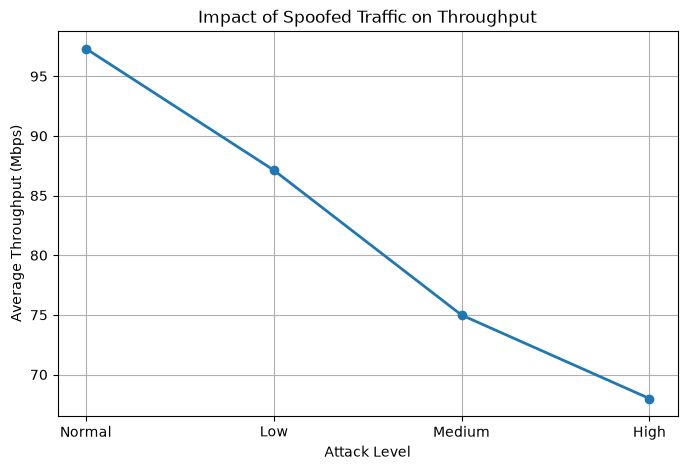

In [59]:
# Throughput vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Throughput_Mbps"],
    marker='o',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Throughput (Mbps)")

plt.title("Impact of Spoofed Traffic on Throughput")

plt.grid(True)

plt.savefig(
    "figures_step8_throughput_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

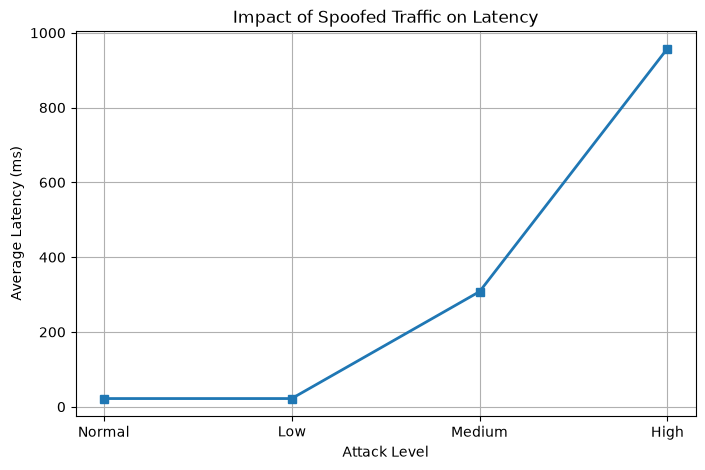

In [60]:
#Latency vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Latency_ms"],
    marker='s',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Latency (ms)")

plt.title("Impact of Spoofed Traffic on Latency")

plt.grid(True)

plt.savefig(
    "figures_step8_latency_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

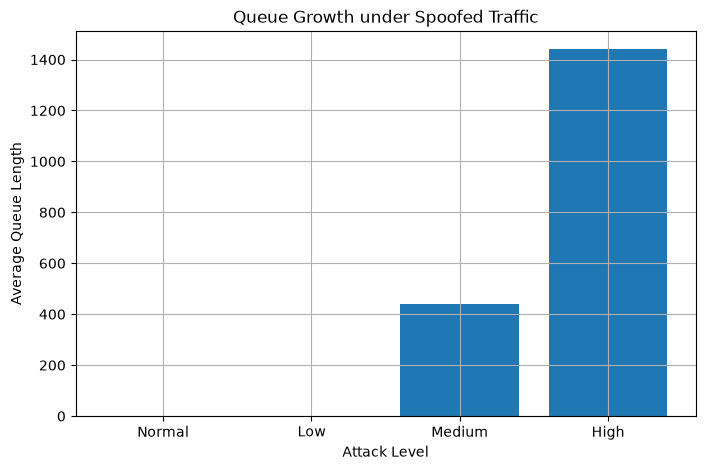

In [61]:
# Queue Length
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Queue_Packets"]
)

plt.xlabel("Attack Level")

plt.ylabel("Average Queue Length")

plt.title("Queue Growth under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_queue_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

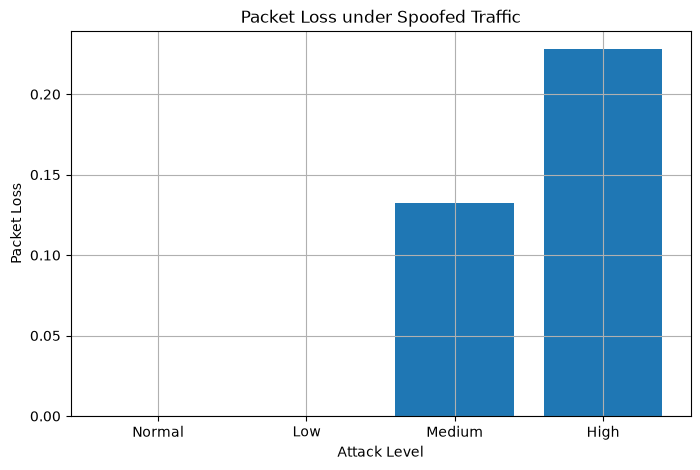

In [62]:
# Packet Loss
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Packet_Loss"]
)

plt.xlabel("Attack Level")

plt.ylabel("Packet Loss")

plt.title("Packet Loss under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_packet_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

TensorFlow: 2.20.0
Sionna: 2.0.1
Modules Imported Successfully


In [64]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([1 1 0 1 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0], shape=(20,), dtype=int32)


In [65]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[ 1.  1. -1.  1.  1. -1. -1.  1. -1. -1. -1.  1.  1. -1. -1. -1.  1. -1.
 -1. -1.], shape=(20,), dtype=float32)


In [66]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: []
Length of BER: 0
[]


In [67]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [68]:
print(ber)
len(ber)

[np.float64(0.078), np.float64(0.0385), np.float64(0.0126), np.float64(0.0023), np.float64(0.0002), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


11

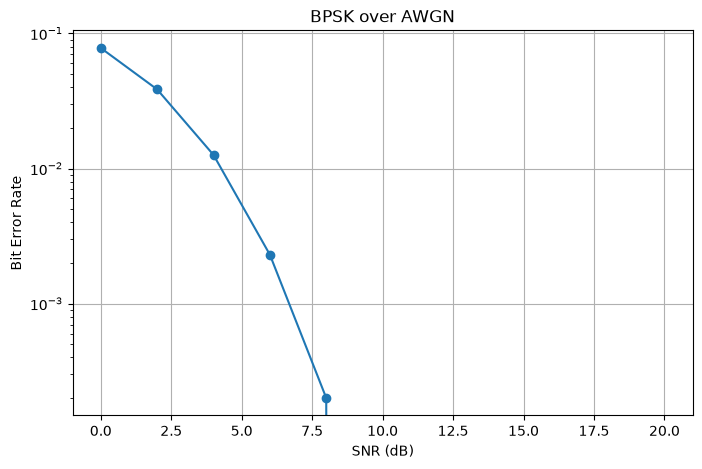

In [69]:
SNR_dB = np.arange(0,21,2)
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
import sionna

print(dir(sionna))
print("Sionna Version:", sionna.__version__)

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']
Sionna Version: 2.0.1


In [71]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [72]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']


In [73]:
import pkgutil
import sionna.phy

print("Available PHY Packages\n")

for module in pkgutil.iter_modules(sionna.phy.__path__):
    print(module.name)

Available PHY Packages

block
channel
config
constants
fec
mapping
mimo
nr
object
ofdm
signal
utils


In [74]:
import sionna.phy.channel

print(dir(sionna.phy.channel))

import sionna.phy.ofdm

print(dir(sionna.phy.ofdm))

import sionna.phy.channel as ch

print(dir(ch))

import sionna.phy.ofdm as ofdm

print(dir(ofdm))


['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [75]:
# ======================================================
# STEP 10 - Sionna PHY Integration
# Small-Scale Fading
# ======================================================

import tensorflow as tf
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

num_users = len(user_positions)

In [76]:
# Rayleigh fading coefficient

# Real part
real = tf.random.normal([num_users], dtype=tf.float32)

# Imaginary part
imag = tf.random.normal([num_users], dtype=tf.float32)

# Create complex channel coefficients
h = tf.complex(real, imag) / tf.cast(tf.sqrt(2.0), tf.complex64)

print(h[:10])

tf.Tensor(
[ 0.23155521+5.9555773e-02j -0.59582645-6.0875088e-01j
  0.22587374+2.6737338e-01j -0.9952895 -3.6743204e-03j
 -1.6886133 -3.4968692e-01j -0.7348592 +4.3686414e-01j
 -0.39408705-2.3392540e-01j  0.38163048-9.7869278e-04j
  1.2016801 -2.9962525e-01j  0.204309  -9.8090470e-01j], shape=(10,), dtype=complex64)


In [77]:
# Channel Power Gain
channel_gain = tf.abs(h)**2

channel_gain = channel_gain.numpy()

print(channel_gain[:10])

[0.0571647  0.7255867  0.12250747 0.9906146  2.973696   0.7308683
 0.2100257  0.14564276 1.5338105  1.003916  ]


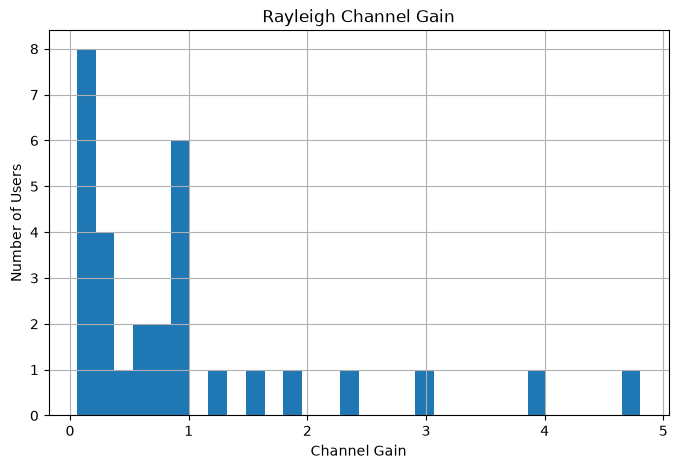

In [78]:
# Plot the Fading Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(channel_gain,
         bins=30)

plt.xlabel("Channel Gain")

plt.ylabel("Number of Users")

plt.title("Rayleigh Channel Gain")

plt.grid(True)

plt.savefig(
    "figures_step10_channel_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
received_power
channel_gain = channel_gain.reshape(-1, 1)

received_power_fading = received_power + 10*np.log10(channel_gain)

print(received_power_fading[:10])

[[-78.77434211 -80.27726905 -67.21212036]
 [-61.2868091  -71.42329351 -72.26281631]
 [-71.51414488 -80.07946826 -78.26976542]
 [-67.83688038 -46.93295727 -69.01385927]
 [-61.83037609 -51.7895782  -60.94057175]
 [-61.20465892 -71.25714448 -72.29186992]
 [-77.03951258 -69.37433256 -73.78885135]
 [-78.71920009 -72.57797929 -74.16171161]
 [-61.81043803 -60.55695722 -61.66554297]
 [-55.07874256 -67.2195842  -66.24818635]]


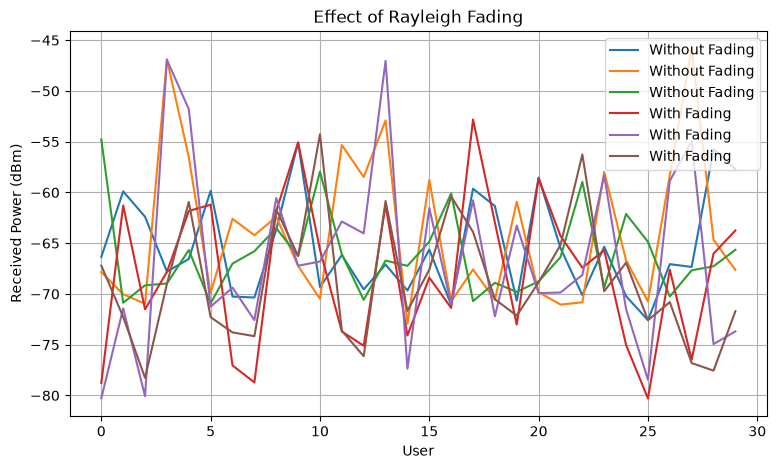

In [80]:
# Plot the Difference
plt.figure(figsize=(9,5))

plt.plot(received_power,
         label="Without Fading")

plt.plot(received_power_fading,
         label="With Fading")

plt.xlabel("User")

plt.ylabel("Received Power (dBm)")

plt.title("Effect of Rayleigh Fading")

plt.legend()

plt.grid(True)

plt.savefig(
    "figures_step10_received_power_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
# Recalculate SINR
received_power_mW = 10**(received_power_fading/10)

noise_power = 1e-10

sinr = received_power_mW / noise_power

sinr_dB = 10*np.log10(sinr)

print(sinr_dB[:10])

[[21.22565789 19.72273095 32.78787964]
 [38.7131909  28.57670649 27.73718369]
 [28.48585512 19.92053174 21.73023458]
 [32.16311962 53.06704273 30.98614073]
 [38.16962391 48.2104218  39.05942825]
 [38.79534108 28.74285552 27.70813008]
 [22.96048742 30.62566744 26.21114865]
 [21.28079991 27.42202071 25.83828839]
 [38.18956197 39.44304278 38.33445703]
 [44.92125744 32.7804158  33.75181365]]


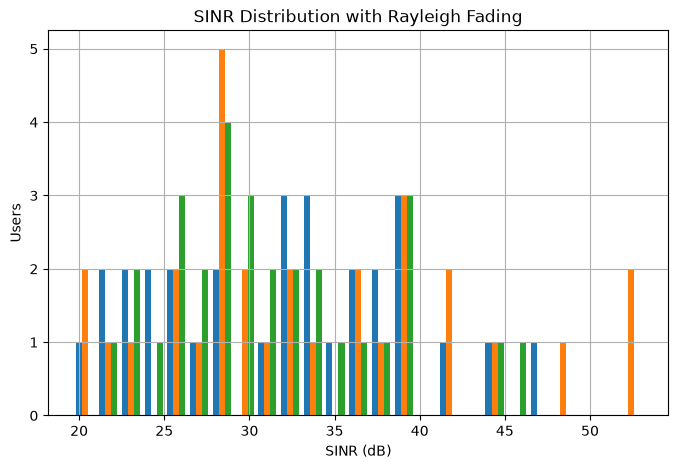

In [82]:
# Compare SINR
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=25)

plt.xlabel("SINR (dB)")

plt.ylabel("Users")

plt.title("SINR Distribution with Rayleigh Fading")

plt.grid(True)

plt.savefig(
    "figures_step10_sinr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
# =====================================================
# STEP 11 - Beamforming
# =====================================================

beamforming_gain_dB = 6

print("Beamforming Gain:", beamforming_gain_dB, "dB")

received_power_beamforming = received_power_fading + beamforming_gain_dB

print(received_power_beamforming[:5])
print(received_power_fading.shape)

Beamforming Gain: 6 dB
[[-72.77434211 -74.27726905 -61.21212036]
 [-55.2868091  -65.42329351 -66.26281631]
 [-65.51414488 -74.07946826 -72.26976542]
 [-61.83688038 -40.93295727 -63.01385927]
 [-55.83037609 -45.7895782  -54.94057175]]
(30, 3)


In [84]:
# Calculate New SINR
received_power_mW = 10 ** (received_power_beamforming / 10)
# Assume:
noise_power_mW = 1e-10

sinr_beam = received_power_mW / noise_power_mW

sinr_beam_dB = 10 * np.log10(sinr_beam)

In [85]:
# Compare Average SINR
print("Average SINR without Beamforming:")

print(np.mean(sinr_dB))

print()

print("Average SINR with Beamforming:")

print(np.mean(sinr_beam_dB))

Average SINR without Beamforming:
32.23288293807634

Average SINR with Beamforming:
38.23288293807634


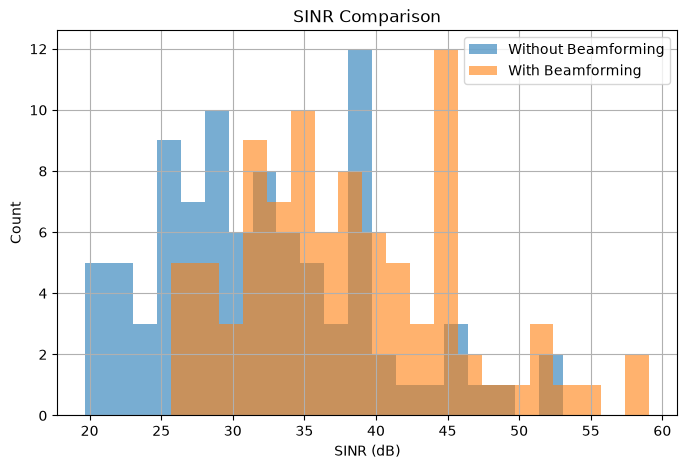

In [86]:
# Plot the Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    sinr_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="Without Beamforming"
)

plt.hist(
    sinr_beam_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="With Beamforming"
)

plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.title("SINR Comparison")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_sinr_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
import numpy as np

# Check the shape first
print("Received power shape:", received_power_beamforming.shape)

# Assign each user to the BS with the highest received power
assignments_beamforming = np.argmax(
    received_power_beamforming,
    axis=1
)

print("User assignments:")
print(assignments_beamforming)

Received power shape: (30, 3)
User assignments:
[2 0 0 1 1 0 1 1 1 0 2 1 1 1 2 1 2 0 0 1 0 0 2 1 2 2 1 1 0 0]


In [88]:
# Count Users Per Base Station
num_bs = received_power_beamforming.shape[1]

users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

BS 1: 10 users
BS 2: 13 users
BS 3: 7 users


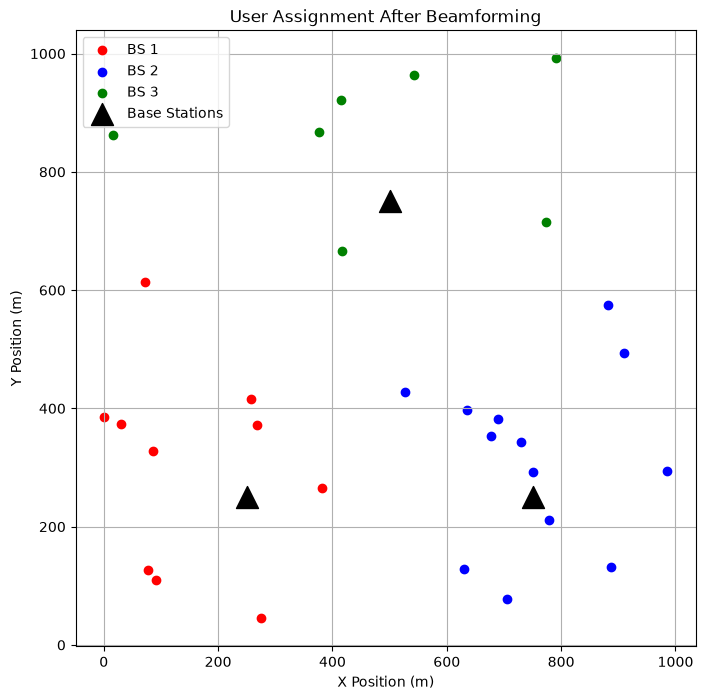

In [89]:
# Visualize User Assignment
colors = ["red", "blue", "green"]

plt.figure(figsize=(8,8))

for bs in range(num_bs):

    users = user_positions[
        assignments_beamforming == bs
    ]

    plt.scatter(
        users[:,0],
        users[:,1],
        color=colors[bs],
        label=f"BS {bs+1}"
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker="^",
    s=250,
    color="black",
    label="Base Stations"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("User Assignment After Beamforming")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_user_assignment_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
# =======================================================
# STEP 12 - Base Station Load Analysis and Visualization
# =======================================================

# STEP 12.1 - Base Station Load Analysis

num_bs = received_power_beamforming.shape[1]

# Number of users connected to each BS
users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

print("===== BASE STATION LOAD =====")

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

print("\nTotal Users:", np.sum(users_per_bs))

===== BASE STATION LOAD =====
BS 1: 10 users
BS 2: 13 users
BS 3: 7 users

Total Users: 30


In [91]:
# STEP 12.2 - Load Percentage

load_percentage = (
    users_per_bs / np.sum(users_per_bs)
) * 100

print("===== BASE STATION LOAD PERCENTAGE =====")

for bs in range(num_bs):
    print(
        f"BS {bs+1}: "
        f"{load_percentage[bs]:.2f}% "
        f"({users_per_bs[bs]} users)"
    )

===== BASE STATION LOAD PERCENTAGE =====
BS 1: 33.33% (10 users)
BS 2: 43.33% (13 users)
BS 3: 23.33% (7 users)


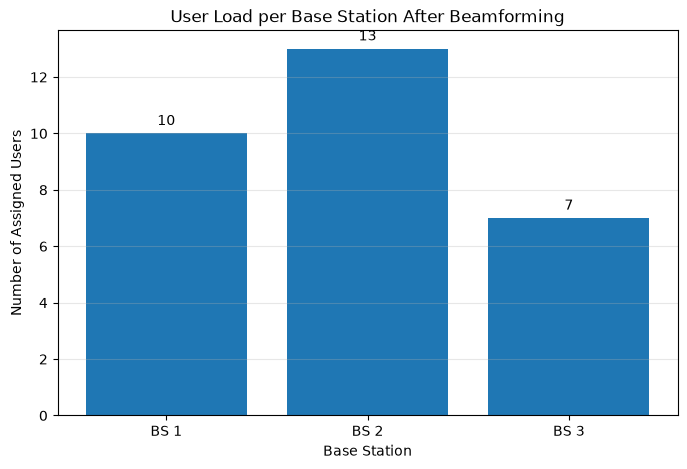

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# STEP 12.3 - Plot Base Station Load

bs_labels = [
    f"BS {i+1}"
    for i in range(num_bs)
]

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    users_per_bs
)

plt.xlabel("Base Station")
plt.ylabel("Number of Assigned Users")
plt.title("User Load per Base Station After Beamforming")

# Add values above bars
for i, value in enumerate(users_per_bs):
    plt.text(
        i,
        value + 0.3,
        str(value),
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

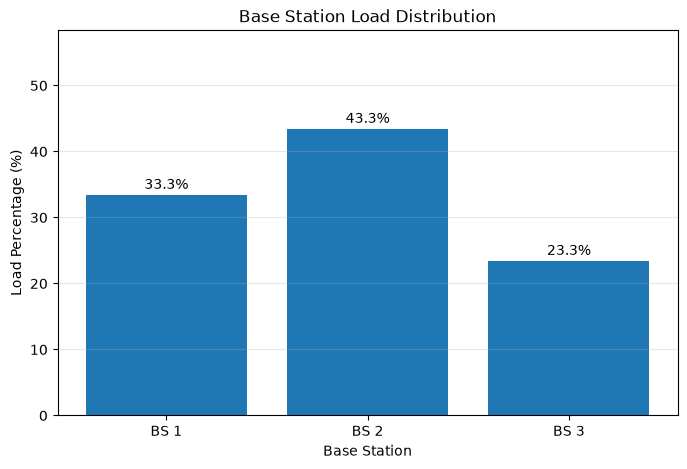

In [93]:
# STEP 12.4 - Base Station Load Percentage

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    load_percentage
)

plt.xlabel("Base Station")
plt.ylabel("Load Percentage (%)")
plt.title("Base Station Load Distribution")

for i, value in enumerate(load_percentage):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(
    0,
    max(load_percentage) + 15
)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [94]:
# ===================================================
# STEP 13 - Realistic Legitimate Traffic Generation
# ===================================================

# STEP 13.1 - Traffic Generation Setup

import numpy as np
import matplotlib.pyplot as plt

# Fixed seed for reproducible traffic generation
np.random.seed(42)

num_users = len(assignments_beamforming)

print("Number of users:", num_users)

Number of users: 30


In [95]:
# STEP 13.2 - Generate Realistic User Traffic

np.random.seed(100)

# Randomly assign traffic types
traffic_type = np.random.choice(
    ["Low", "Medium", "High"],
    size=num_users,
    p=[0.4, 0.4, 0.2]
)

# Create traffic demand in Mbps
user_traffic = np.zeros(num_users)

for i in range(num_users):

    if traffic_type[i] == "Low":
        user_traffic[i] = np.random.uniform(0.5, 2.0)

    elif traffic_type[i] == "Medium":
        user_traffic[i] = np.random.uniform(2.0, 8.0)

    elif traffic_type[i] == "High":
        user_traffic[i] = np.random.uniform(8.0, 20.0)

print("Traffic generated successfully.")
print("\nFirst 10 users:")

for i in range(min(10, num_users)):
    print(
        f"User {i+1}: "
        f"{traffic_type[i]} traffic, "
        f"{user_traffic[i]:.2f} Mbps"
    )

Traffic generated successfully.

First 10 users:
User 1: Medium traffic, 5.59 Mbps
User 2: Low traffic, 1.41 Mbps
User 3: Medium traffic, 2.63 Mbps
User 4: High traffic, 12.58 Mbps
User 5: Low traffic, 0.55 Mbps
User 6: Low traffic, 1.84 Mbps
User 7: Medium traffic, 7.89 Mbps
User 8: High traffic, 8.72 Mbps
User 9: Low traffic, 1.84 Mbps
User 10: Medium traffic, 5.46 Mbps


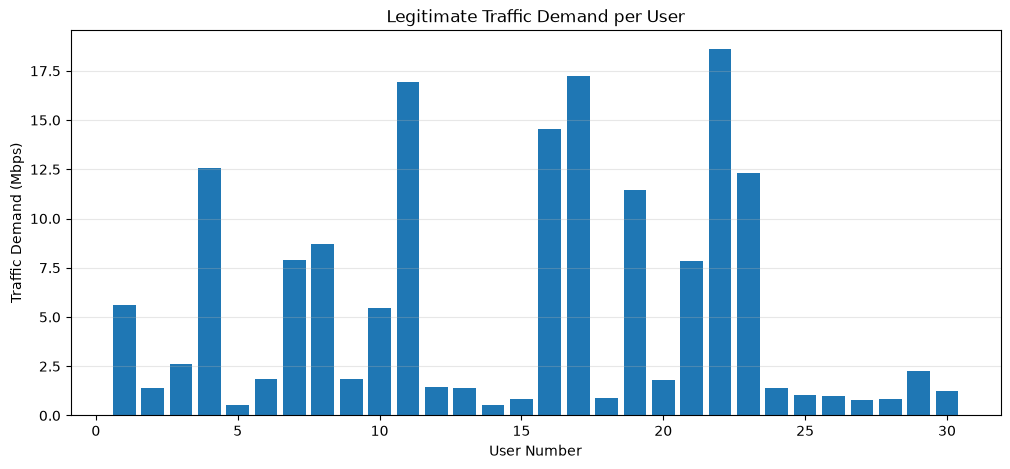

In [96]:
# STEP 13.3 - Plot Traffic Demand per User

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(1, num_users + 1),
    user_traffic
)

plt.xlabel("User Number")
plt.ylabel("Traffic Demand (Mbps)")
plt.title("Legitimate Traffic Demand per User")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [97]:
assignments_beamforming

# STEP 13.4 - Calculate Traffic Load per Base Station

traffic_per_bs = np.zeros(num_bs)

for bs in range(num_bs):

    # Get users assigned to this BS
    bs_users = (
        assignments_beamforming == bs
    )

    # Sum traffic from assigned users
    traffic_per_bs[bs] = np.sum(
        user_traffic[bs_users]
    )

print("===== LEGITIMATE TRAFFIC PER BASE STATION =====")

for bs in range(num_bs):

    print(
        f"BS {bs+1}: "
        f"{traffic_per_bs[bs]:.2f} Mbps"
    )

print(
    "\nTotal Network Traffic:",
    f"{np.sum(traffic_per_bs):.2f} Mbps"
)

===== LEGITIMATE TRAFFIC PER BASE STATION =====
BS 1: 53.64 Mbps
BS 2: 54.26 Mbps
BS 3: 54.90 Mbps

Total Network Traffic: 162.80 Mbps


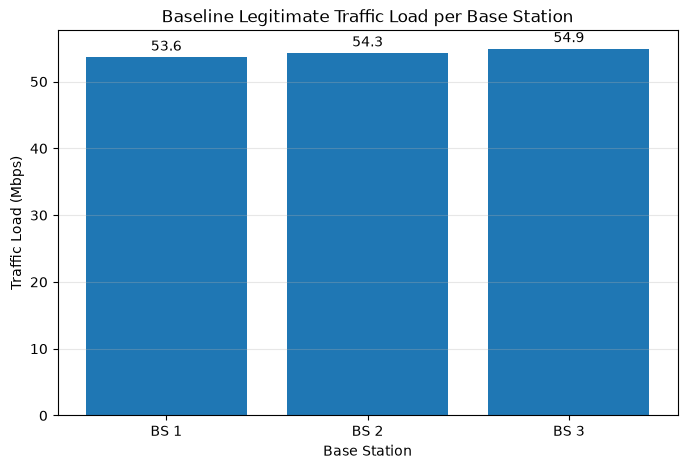

In [98]:
# STEP 13.5 - Visualize Traffic Load per Base Station

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    traffic_per_bs
)

plt.xlabel("Base Station")
plt.ylabel("Traffic Load (Mbps)")
plt.title("Baseline Legitimate Traffic Load per Base Station")

# Add traffic values above bars
for i, value in enumerate(traffic_per_bs):

    plt.text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

In [99]:
# STEP 13.6 - User Traffic Summary

import pandas as pd

traffic_summary = pd.DataFrame({
    "User": np.arange(1, num_users + 1),
    "Traffic Type": traffic_type,
    "Traffic Demand (Mbps)": np.round(user_traffic, 2),
    "Assigned BS": assignments_beamforming + 1
})

traffic_summary

,User,Traffic Type,Traffic Demand (Mbps),Assigned BS
0,1,Medium,5.59,3
1,2,Low,1.41,1
2,3,Medium,2.63,1
3,4,High,12.58,2
4,5,Low,0.55,2
5,6,Low,1.84,1
6,7,Medium,7.89,2
7,8,High,8.72,2
8,9,Low,1.84,2
9,10,Medium,5.46,1
